In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def process_timestamp(dataframe, cutoffdate):
    """
    dataframe
    cutoffdate (pandas datetime): date you want to start processing data from
    """
    def ensure_form(t):
        if t is np.nan: return pd.NaT
        else: return pd.to_datetime(t.get('$date', pd.NaT))

    assert 'timestamp' in dataframe.columns, "Timestamp not in dataframe"
    dataframe['timestamp'] = dataframe['timestamp'].apply(ensure_form, 1)
    timeMask = dataframe.apply(lambda x: x.timestamp >= cutoffdate, 1)

    return dataframe[timeMask]

In [4]:
prolificInfo1 = pd.read_csv(f"usersround1/prolificParticipantInfo.csv")
prolificInfo2 = pd.read_csv(f"usersround2/prolificParticipantInfo.csv")

All people that started:  513
All people paid:  412
All people paid:  412


/var/folders/04/dgz4d5cn0v732mbzpk64d_rc0000gn/T/ipykernel_71181/3975640212.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subDf['Time taken (min)'] = subDf['Time taken'] / 60


<Axes: >

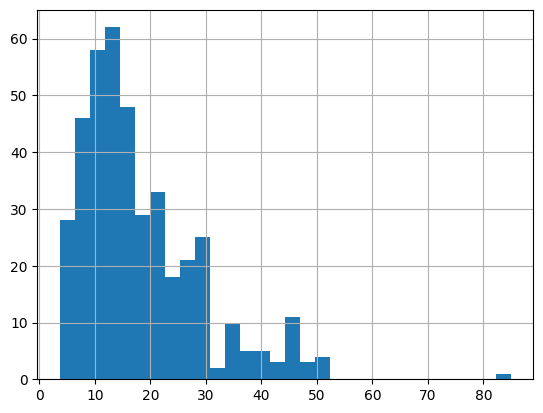

In [5]:
prolificInfo = pd.concat([prolificInfo1, prolificInfo2]).reset_index()
print("All people that started: ", len(prolificInfo))
prolificInfoPaid = prolificInfo[prolificInfo.Status == 'APPROVED']
print("All people paid: ", len(prolificInfoPaid))
prolificInfoFinal = prolificInfoPaid[prolificInfoPaid['Completion code'] != 'CONSENT_REVOKED']
print("All people paid: ", len(prolificInfoFinal))
subDf = prolificInfoFinal[['Participant id', 'Status', 'Time taken']]
prolificValidated = set(subDf['Participant id'])
subDf['Time taken (min)'] = subDf['Time taken'] / 60
subDf['Time taken (min)'].hist(bins=30)

In [6]:
file_path = 'usersround2'
start_date_naive = pd.to_datetime('06-30-2025')
start_date = start_date_naive.tz_localize('US/Eastern')
comments_df_all = pd.read_json(f"{file_path}/comments.json", lines=True)
participants_df = pd.read_csv(f'{file_path}/processed_data/participants.csv')

eligibleUsers = set(participants_df['user_id']).intersection(prolificValidated)
commentsDf = process_timestamp(comments_df_all, start_date)
print(len(set(commentsDf.user_id)))
print(len(eligibleUsers))
commentsMask = commentsDf['user_id'].isin(eligibleUsers)
commentsDfSubset = commentsDf[commentsMask].copy()
commentsDfSubset = commentsDfSubset[commentsDfSubset.sender == 'user']
len(set(commentsDfSubset.user_id))
commentsDfSubset.to_csv('usersround2/processed_data/allComments.csv')

/var/folders/04/dgz4d5cn0v732mbzpk64d_rc0000gn/T/ipykernel_71181/2429779041.py:11: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  dataframe['timestamp'] = dataframe['timestamp'].apply(ensure_form, 1)


432
401


In [7]:
# SIDE MISSION: DO THE COMMENTS LOOK LEGIT?
lengthOfConvo = {}
uniqueComments = {}
commentsLongerThan3Characters = {}
duration = {}
grouped_comments = commentsDfSubset[commentsDfSubset.posted == True].groupby('user_id')
for group in grouped_comments.groups:
    userConvo = grouped_comments.get_group(group)
    longComments = 0
    lengthOfConvo[group] = len(userConvo)
    for i in list(userConvo['comment']):
        if len(i) > 3: longComments += 1
    commentsLongerThan3Characters[group] = longComments
    noDupes = userConvo.drop_duplicates(subset=['comment'])
    uniqueComments[group] = len(noDupes)
    earliestComment = min(userConvo['timestamp'])
    latestComment = max(userConvo['timestamp'])
    duration[group] = (latestComment - earliestComment).total_seconds() / 60

# Combine all the dictionaries into a DataFrame
df = pd.DataFrame({
    'number_comments': lengthOfConvo,
    'unique_comments': uniqueComments,
    'comments_longer_than_3_chars': commentsLongerThan3Characters,
    'duration_minutes': duration
})

# Set the index name for clarity (optional)
df.index.name = 'user_id'

Text(0.5, 1.0, 'Num Minutes / User')

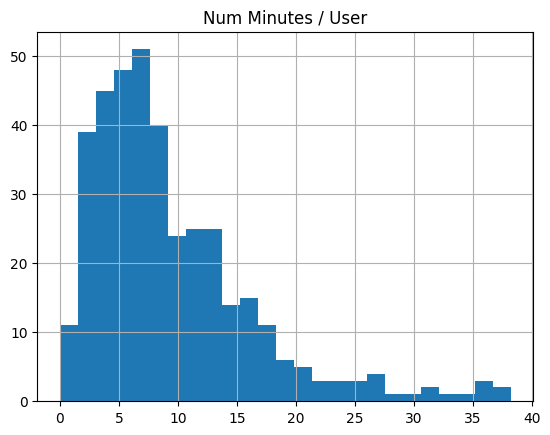

In [8]:
df['duration_minutes'].hist(bins=25)
plt.title("Num Minutes / User")

In [9]:
lessThan4Comments = set(df[df.number_comments < 4].index)
len(lessThan4Comments)

28

In [10]:
grouped_comments.get_group('65a3eab844b50c6810ea62f3').sort_values('timestamp')

,_id,user_id,post_id,parent_id,comment,timestamp,posted,sender
16764,{'$oid': '6862cc0a98e7cf91c33c7d1b'},65a3eab844b50c6810ea62f3,{'$oid': '9a54aea563eaf7800543f418'},{'$oid': '6862cb0e70bef01e9c308806'},Immigration should always follow lawful proced...,2025-06-30 17:40:26.082000+00:00,True,user
16776,{'$oid': '6862cc523a8e7dd210a82719'},65a3eab844b50c6810ea62f3,{'$oid': '9a54aea563eaf7800543f418'},{'$oid': '6862cc0c98e7cf91c33c7d1c'},the laws are meant to be followed strictly. Th...,2025-06-30 17:41:38.935000+00:00,True,user
16784,{'$oid': '6862cc6f98e7cf91c33c7d2c'},65a3eab844b50c6810ea62f3,{'$oid': '9a54aea563eaf7800543f418'},{'$oid': '6862cb0e70bef01e9c308807'},Immigration should always follow lawful proced...,2025-06-30 17:42:07.963000+00:00,True,user
16826,{'$oid': '6862cd16edd08b980b99f616'},65a3eab844b50c6810ea62f3,{'$oid': '9a54aea563eaf7800543f419'},{'$oid': '6862cb0e70bef01e9c308808'},It’s truly disheartening to see how the govern...,2025-06-30 17:44:54.035000+00:00,True,user
16871,{'$oid': '6862cd77edd08b980b99f634'},65a3eab844b50c6810ea62f3,{'$oid': '9a54aea563eaf7800543f419'},{'$oid': '6862cb0e70bef01e9c308809'},These laws and processes need to be thoroughly...,2025-06-30 17:46:31.227000+00:00,True,user
16901,{'$oid': '6862ce126efe810e8eb14bf6'},65a3eab844b50c6810ea62f3,{'$oid': '9a54aea563eaf7800543f419'},{'$oid': '6862cd1bedd08b980b99f617'},"Immigration must be handled the right way, thr...",2025-06-30 17:49:06.109000+00:00,True,user


In [11]:
moreThanFourMask = commentsDfSubset['user_id'].isin(lessThan4Comments)
commentsToLabel = commentsDfSubset[~moreThanFourMask]
commentsToLabel = commentsDfSubset[['_id', 'comment']].drop_duplicates(subset=['comment'])

In [12]:
from testClassifiers import *

myModel = 'gpt-4.1'
file_path = 'prompt.txt'  # Replace with the actual path to your .txt file
with open(file_path, 'r') as file:
    myPrompt= file.read()

labelType = 'coarse'
mySubLabels = ['IH', 'IA', 'Neutral']
IHClassifier = myClassifier(myModel, myPrompt, labelType, mySubLabels)
try:
    commentsToLabel['classification'] = commentsToLabel.swifter.apply(lambda x: IHClassifier.label(x.comment), 1)
except:
    commentsToLabel.to_csv('emergency.csv')
commentsToLabel.to_csv('labeled_data.csv')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
#commentsToLabel['classification_string'] = commentsToLabel['classification'].apply(lambda x: x[0], 1)
commentsToLabel.to_csv('labeledDataClean.csv')

In [15]:
allComments = commentsDfSubset[~moreThanFourMask]

In [16]:
allComments.to_csv('usersround2/processed_data/valid_comments.csv')